## Learning Glassy

### The mental model
Glassy has two classes, and they answer different questions about **the set of good models**: all models whose training loss is within a tolerance `r` of the model with the lowest loss.

| Class | Question it answers |
|---|---|
| `Prism` | Let's you explore the set of good models 
| `Spec` | Let's you grab specific models in and around the set

The usual flow: engineer feature and fit with sklearn as normal, explore with `Prism`, then pick with `Spec`.

### Contents
1. Setup
2. `Prism`: construction and the loss radius `r`
3. `Prism.coef_bounds`
4. `Prism.droppable` and `query_droppable`
5. `Prism.disagreement`
6. `Spec`: `from_coef`, `sans_features`, `check_mse`
7. Cheat sheet

----

### 1. Set up the data and base model

In [ ]:
pip install numpy scikit-learn pandas matplotlib glassy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import glassy as gls

In [2]:
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

mu, sigma = X_train.mean(), X_train.std()
X_train, X_test = (X_train - mu) / sigma, (X_test - mu) / sigma

model = LinearRegression().fit(X_train, y_train)
best_mse = mean_squared_error(y_train, model.predict(X_train))
print(f"Optimal train MSE: {best_mse:.4f}")

Optimal train MSE: 0.5234


**!Important notes:**
- Features should be engineered before setting up models sent to glassy--i.e. no higher order or interaction terms in the regression itself
- Glassy 1.0 is squared-error only. We pass a plain OLS `LinearRegression`.

### 2. `Prism`: construction and the loss radius

```python
prism = gls.Prism(model, X_train, y_train, r=2.5)
```
- `model`: an already-fitted sklearn-style linear regressor (needs `coef_`, `intercept_`, and `fit_intercept=True`). Its training MSE is the **baseline** that `r` is measured against. The set itself is always centered on the exact OLS solution, so for a plain `LinearRegression` the baseline is simply the optimum.
- `X_train`, `y_train`: the data the model was fitted on. Loss is defined on these data.
- `r`: the admissible loss radius, i.e. how much worse than the baseline a model may be and still count as "good".
- `units` (optional): how to read `r`, `"percent"` (default) or `"raw"`. See below.

All init data is stored on the object, e.g. `prism.r`.

In [3]:
prism = gls.Prism(model, X_train, y_train, r=2.5)
print(f"r = {prism.r} ({prism.units})")
print(f"baseline train MSE: {prism.baseline_loss:.4f}")
print(f"allowed train MSE:  {prism.allowed_loss:.4f}  # any model at or below this is 'good'")

r = 2.5 (percent)
baseline train MSE: 0.5234
allowed train MSE:  0.5365  # any model at or below this is 'good'


**No model yet?** `Prism.from_data(X, y, r=1.0, units="percent")` fits an OLS reference model for you and builds the Prism in one line.

In [4]:
prism_from_data = gls.Prism.from_data(X_train, y_train, r=2.5)
print(f"baseline train MSE: {prism_from_data.baseline_loss:.4f}")

baseline train MSE: 0.5234


**Useful attributes:** `prism.baseline_loss`, `prism.allowed_loss` (the MSE ceiling for "good"), `prism.coef_` and `prism.intercept_` (the OLS solution at the center of the set), `prism.feature_names`, and `prism.get_coefs()` which returns the coefficients and their names. `prism.spec()` builds a `Spec` over the same model and data.

#### Choosing and changing `r`
`update_r(r, units=None)` changes the radius **in place**. There are two units:
- `"percent"`: `r=2` means allowed training MSE = baseline x 1.02.
- `"raw"`: `r` is **added** to the baseline, in MSE units. `r=0.01` means allowed MSE = baseline + 0.01.

`prism.allowed_loss` shows the resulting MSE ceiling. Below, a 2% budget and its raw equivalent land on the same ceiling.

In [5]:
prism.update_r(2, units="percent")
print(f"2% -> allowed MSE {prism.allowed_loss:.4f}")

prism.update_r(0.02 * prism.baseline_loss, units="raw")
print(f"same budget as raw -> allowed MSE {prism.allowed_loss:.4f}  (r={prism.r:.4f}, units={prism.units!r})")

prism.update_r(3, units="percent")  # switch back explicitly (see the quirk below)

2% -> allowed MSE 0.5339
same budget as raw -> allowed MSE 0.5339  (r=0.0105, units='raw')


**Quirk: `update_r` mutates the Prism, and the units stick.** Every later call (`coef_bounds`, `droppable`, `disagreement`) uses whatever `r` was set last. If you tighten `r` for one question, set it back afterward, or keep one Prism per question. Passing `units=None` (the default) keeps the *last* units, so after using `"raw"` a plain `update_r(3)` means 3 MSE units, not 3%. When in doubt, pass `units` explicitly.

#### How sensitive are results to `r`?
`r` is a judgment call, so it's worth looking at how quickly the picture changes. Here is the width of each coefficient's interval as `r` grows.

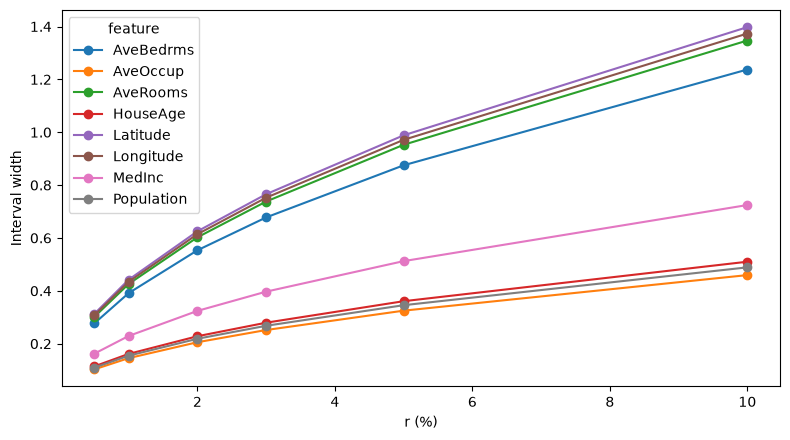

In [6]:
rows = []
for r in [0.5, 1, 2, 3, 5, 10]:
    prism.update_r(r)
    for feat, (lo, hi) in prism.coef_bounds().items():
        rows.append({'r': r, 'feature': feat, 'width': hi - lo})
sweep = pd.DataFrame(rows).pivot(index='r', columns='feature', values='width')

ax = sweep.plot(marker='o', figsize=(8, 4.5))
ax.set_xlabel("r (%)"); ax.set_ylabel("Interval width")
plt.tight_layout(); plt.show()
prism.update_r(3)  # reset

Features whose widths grow slowly are well pinned down by the data. Features that open up quickly are where "optimal" was doing arbitrary work.

### 3. `Prism.coef_bounds`

```python
prism.coef_bounds(features=None, magnitude=False, mode="both") -> dict
```
Returns, for each feature, the smallest and largest coefficient among all good models: `{feature: [min, max]}`.

| Argument | What it does |
|---|---|
| `features` | Restrict to a subset of feature names. Default: all. |
| `magnitude` | If `True`, bound the **absolute value** of each coefficient instead of the signed value. |
| `mode` | `"both"` (default), or `"min"` / `"max"` to get only one end of the interval (returned as a one-element list). |

In [7]:
prism.update_r(3)
print("All features, signed:")
for item in prism.coef_bounds().items(): print("  ", item)

print("\nSubset of features:")
print(prism.coef_bounds(features=['MedInc', 'AveRooms']))

print("\nOnly the max / only the min:")
print(prism.coef_bounds(features=['MedInc'], mode="max"))
print(prism.coef_bounds(features=['MedInc'], mode="min"))

All features, signed:
   ('MedInc', [0.6278383149508262, 1.0247075956628529])
   ('HouseAge', [-0.022600879035889754, 0.2568091746392064])
   ('AveRooms', [-0.6178367760827652, 0.12000052182774762])
   ('AveBedrms', [-0.04847206572524987, 0.6292645648373205])
   ('Population', [-0.14250415102311148, 0.12521664131698873])
   ('AveOccup', [-0.15640520649701184, 0.09527478374132327])
   ('Latitude', [-1.283246913153447, -0.5176498586090876])
   ('Longitude', [-1.2467740415952537, -0.49445000043043497])

Subset of features:
{'MedInc': [0.6278383149508262, 1.0247075956628529], 'AveRooms': [-0.6178367760827652, 0.12000052182774762]}

Only the max / only the min:
{'MedInc': [1.0247075956628529]}
{'MedInc': [0.6278383149508262]}


#### Signed vs. magnitude: two different questions
- **Signed** (default) answers: *can the effect flip direction?* An interval like `[-0.1, 0.3]` says yes, and that a model with this feature at exactly 0 exists.
- **Magnitude** answers: *how small or large can its influence get, ignoring direction?* A minimum magnitude of 0 means some good model doesn't need the feature. If the minimum is above 0, that is the least influence any good model gives it.

In [8]:
signed = pd.DataFrame(prism.coef_bounds(), index=['min', 'max']).T
mag = pd.DataFrame(prism.coef_bounds(magnitude=True), index=['min |coef|', 'max |coef|']).T
pd.concat([signed, mag], axis=1).round(3)

,min,max,min |coef|,max |coef|
MedInc,0.628,1.025,0.628,1.025
HouseAge,-0.023,0.257,0.000,0.257
AveRooms,-0.618,0.120,0.000,0.618
AveBedrms,-0.048,0.629,0.000,0.629
Population,-0.143,0.125,0.000,0.143
AveOccup,-0.156,0.095,0.000,0.156
Latitude,-1.283,-0.518,0.518,1.283
Longitude,-1.247,-0.494,0.494,1.247


### 4. `Prism.droppable` and `query_droppable`

```python
prism.droppable(max_terms=1) -> list of feature lists
prism.query_droppable(features) -> bool
```
`droppable` lists the feature subsets (up to `max_terms` features each; `None` for no limit) that can be removed **together**, with the remaining coefficients re-fit, while the model stays within `r`. The default `max_terms=1` returns single features only. `query_droppable` answers the same question for one set you specify and returns a bool.

**Quirk: the output is redundant.** If `{A, B}` is droppable then `{A}` and `{B}` are too, so the list is full of subsets of other entries. Usually you want only the *maximal* sets, the ones that can't be extended.

In [9]:
prism.update_r(3)
print("Droppable one at a time:", [s[0] for s in prism.droppable()])

all_sets = prism.droppable(max_terms=None)
print(len(all_sets), "droppable subsets in total")

candidates = [frozenset(s) for s in all_sets]
maximal = sorted([sorted(s) for s in candidates if not any(s < t for t in candidates)], key=len, reverse=True)
print("\nMaximal droppable sets:")
for s in maximal: print("  ", s)

Droppable one at a time: ['HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
19 droppable subsets in total

Maximal droppable sets:
   ['AveBedrms', 'AveOccup', 'AveRooms', 'Population']
   ['AveOccup', 'HouseAge', 'Population']


In [10]:
# Check a specific set you have in mind: returns True/False for "can I drop these together?"
print(prism.query_droppable(['Population']))
print(prism.query_droppable(['MedInc']))

True
False


`max_terms` caps the subset size. The search only tests a subset if all of its smaller subsets were droppable, so it prunes aggressively, but on wide data a modest cap keeps it fast.

### 5. `Prism.disagreement`

```python
prism.disagreement(X=None) -> {"min": ..., "optimal": ..., "max": ...}
```
For every row of `X` (default: the training data), the lowest and highest prediction that any good model could make, next to the optimal model's prediction. This is a direct measure of **predictive multiplicity**. Pass new rows, such as a test set, to see disagreement on data the models weren't fit to. A 1-D `X` is treated as a single row. Wrap the result in a DataFrame to work with it.

In [11]:
prism.update_r(1)
dis = pd.DataFrame(prism.disagreement())
dis['width'] = dis['max'] - dis['min']
dis.head()

,min,optimal,max,width
0,1.476722,1.725911,1.975100,0.498378
1,2.694921,2.885439,3.075957,0.381037
2,2.090451,2.200646,2.310841,0.220389
3,1.234420,1.382820,1.531221,0.296801
4,2.050858,2.220702,2.390546,0.339688


Two useful summaries:
- **Spread:** how wide is the prediction range per row? (`width` above)
- **Decision flips:** for how many rows does the range *straddle a decision threshold*? That's the number that matters when a score becomes an action.

> **Quirk:** a range that contains 0 is only meaningful if 0 means something in your target. Pick a threshold tied to a real decision (a cutoff, a median, a price point).

In [12]:
threshold = y_train.median()
straddles = (dis['min'] <= threshold) & (threshold <= dis['max'])
print(f"{straddles.mean():.1%} of rows straddle the threshold at r = {prism.r}%")

# Rows with the largest disagreement
dis.sort_values('width', ascending=False).head()

16.3% of rows straddle the threshold at r = 1.0%


,min,optimal,max,width
10038,-8.271973,-1.549176,5.173622,13.445595
4647,-5.240799,0.381569,6.003937,11.244736
11863,3.164795,8.367671,13.570546,10.405751
1520,-3.209990,1.201684,5.613358,8.823348
7483,-1.055084,1.517922,4.090927,5.146011


In [13]:
# Same question on held-out rows
dis_test = pd.DataFrame(prism.disagreement(X_test))
straddles_test = (dis_test['min'] <= threshold) & (threshold <= dis_test['max'])
print(f"{straddles_test.mean():.1%} of test rows straddle the threshold at r = {prism.r}%")

prism.update_r(3)  # reset

17.3% of test rows straddle the threshold at r = 1.0%


### 6. `Spec`: build specific models

```python
spec = gls.Spec(model, X_train, y_train)
```
`Prism` tells you what's *possible*. `Spec` (short for spectrometer) returns an actual model once you've decided what you want. Every builder returns a model of the same class as the original, **full width** (same columns as `X`, with pinned coefficients set to their values and everything else re-fit by least squares). The original is available as `spec.model`. Shortcut: `prism.spec()` builds a `Spec` over the same model and data.

| Method | Returns |
|---|---|
| `spec.from_coef(feature, value)` | The best-fitting model with that one feature's coefficient **pinned** to `value`. |
| `spec.sans_features(features)` | The best-fitting model with those features removed. Takes one name or a list. |
| `spec.check_mse(model=None, X=None, y=None)` | Mean squared error of a model on data. With no arguments, scores the original model on the Spec's own data. |

In [15]:
spec = gls.Spec(model, X_train, y_train)

print("Original model, train:", round(spec.mse(spec.model, X_train, y_train), 4))
print("Original model, test: ", round(spec.mse(spec.model, X_test, y_test), 4))

Original model, train: 0.5234
Original model, test:  0.529


**Why `check_mse` instead of sklearn's `mean_squared_error`?** It handles feature-name alignment between the model and the data you pass (DataFrame or array), and its defaults let `spec.check_mse()` score the original model on the Spec's own data. Spec models are full width, so the same `X_test` works for every one of them: dropped features are pinned at zero, not removed from the columns.

#### `sans_features`

In [17]:
print("Drop Population:         ", round(spec.mse(spec.sans_features('Population'), X_train, y_train), 4))
print("Drop two (list of names):", round(spec.mse(spec.sans_features(['Population', 'AveOccup']), X_train, y_train), 4))

Drop Population:          0.5235
Drop two (list of names): 0.5245


#### `from_coef`
Pinning a coefficient to a value forces that coefficient and re-optimizes everything else. Two uses:
1. **Pin to 0.** Equivalent to dropping the feature, so `from_coef(f, 0)` and `sans_features(f)` give the same model.
2. **Pin to a nonzero value.** Encode a domain belief: "the income effect should be about this big".

In [22]:
print("Pin to 0:    ", round(spec.mse(spec.from_coefs({'Population': 0}), X_train, y_train), 4))
print("sans_features:", round(spec.mse(spec.sans_features('Population'), X_train, y_train), 4))

lo, hi = prism.coef_bounds(['MedInc'])['MedInc']
for frac in (0.0, 0.25, 0.5, 1.0):
    v = lo + frac * (hi - lo)
    print(f"MedInc pinned at {v:.3f}  ->  train MSE {spec.mse(spec.from_coefs({'MedInc': v}), X_train, y_train):.4f}")

Pin to 0:     0.5235
sans_features: 0.5235
MedInc pinned at 0.628  ->  train MSE 0.5391
MedInc pinned at 0.727  ->  train MSE 0.5274
MedInc pinned at 0.826  ->  train MSE 0.5234
MedInc pinned at 1.025  ->  train MSE 0.5391


**`Spec` knows nothing about `r`.** It pins whatever you ask and re-fits the rest, even if the result is no longer a good model. `coef_bounds` tells you which values are feasible; to verify any Spec model, compare its training MSE to `prism.allowed_loss`.

In [24]:
for label, v in [("inside the range ", lo + 0.5 * (hi - lo)), ("outside the range", hi + (hi - lo))]:
    loss = spec.mse(spec.from_coefs({'MedInc': v}), X_train, y_train)
    print(f"{label}: MedInc={v:.3f}  train MSE {loss:.4f}  allowed {prism.allowed_loss:.4f}  in set: {loss <= prism.allowed_loss}")

inside the range : MedInc=0.826  train MSE 0.5234  allowed 0.5391  in set: True
outside the range: MedInc=1.422  train MSE 0.6648  allowed 0.5391  in set: False


### 7. Cheat sheet

| Call | Use it to | Notes |
|---|---|---|
| `Prism(model, X, y, r=1.0, units="percent")` | Start exploring | `model` is a fitted linear regressor; its MSE is the baseline |
| `Prism.from_data(X, y, r=1.0, units="percent")` | Start without a model | Fits OLS for you |
| `prism.baseline_loss`, `prism.allowed_loss` | See the MSE ceiling for "good" | Changes with `update_r` |
| `prism.update_r(r, units=None)` | Change "how good is good" | `"raw"` is added MSE; mutates in place; units stick |
| `prism.coef_bounds(features=None, magnitude=False, mode="both")` | Min/max coefficient across good models | `magnitude=True` bounds `|coef|` |
| `prism.droppable(max_terms=1)` | Which feature sets can be dropped together | `None` = no cap; output includes subsets |
| `prism.query_droppable(features)` | Test a specific set | Returns a bool |
| `prism.disagreement(X=None)` | Per-row prediction range | Pass `X_test` for held-out rows; compare to a decision threshold |
| `Spec(model, X, y)` or `prism.spec()` | Build specific models | Original at `spec.model`; knows nothing about `r` |
| `spec.from_coef(feature, value)` | Pin a coefficient | `0` equals dropping the feature |
| `spec.sans_features(features)` | Remove features | One name or a list |
| `spec.check_mse(model=None, X=None, y=None)` | Score any Spec model | Aligns feature names; no args scores the original on its own data |

### The whole workflow in a dozen lines
```python
model = LinearRegression().fit(X_train, y_train)      # your usual training
prism = gls.Prism(model, X_train, y_train, r=3)       # what's good enough?
prism.coef_bounds()                                    # do good models agree on effects?
prism.droppable(max_terms=None)                        # what's optional?
prism.disagreement()                                   # do they disagree on predictions?
spec = gls.Spec(model, X_train, y_train)
final = spec.sans_features(['Population', 'AveOccup']) # or spec.from_coef('MedInc', 0.4)
spec.check_mse(final, X_test, y_test)                  # always check held-out performance
```